# CEI Internship Program 2026 — Week 6 Assignment
Author: Sankalp Tamboli:

# Autoencoder MNIST

## Importing required packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

## Defining transforms

In [2]:
transforms=transforms.ToTensor()

## Downloading requried data

In [3]:
train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)

## Defining dataloaders

In [4]:
valid_size=0.2

# IMPORTANT
batch_size=20

num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)

In [5]:

# Printing the length of our train, valid and test dataloaders
# NOTE : Here batch size is 20
len(train_loader),len(valid_loader),len(test_loader)

(2400, 600, 500)

In [6]:
# checking our data
dataiter=iter(train_loader)
images,labels=next(dataiter)
print(images, images.shape, len(images), images[0].shape)
print()
print(labels,labels.shape,len(labels))

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

In [7]:
def add_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0., 1.)

## Visualizing a Training batch

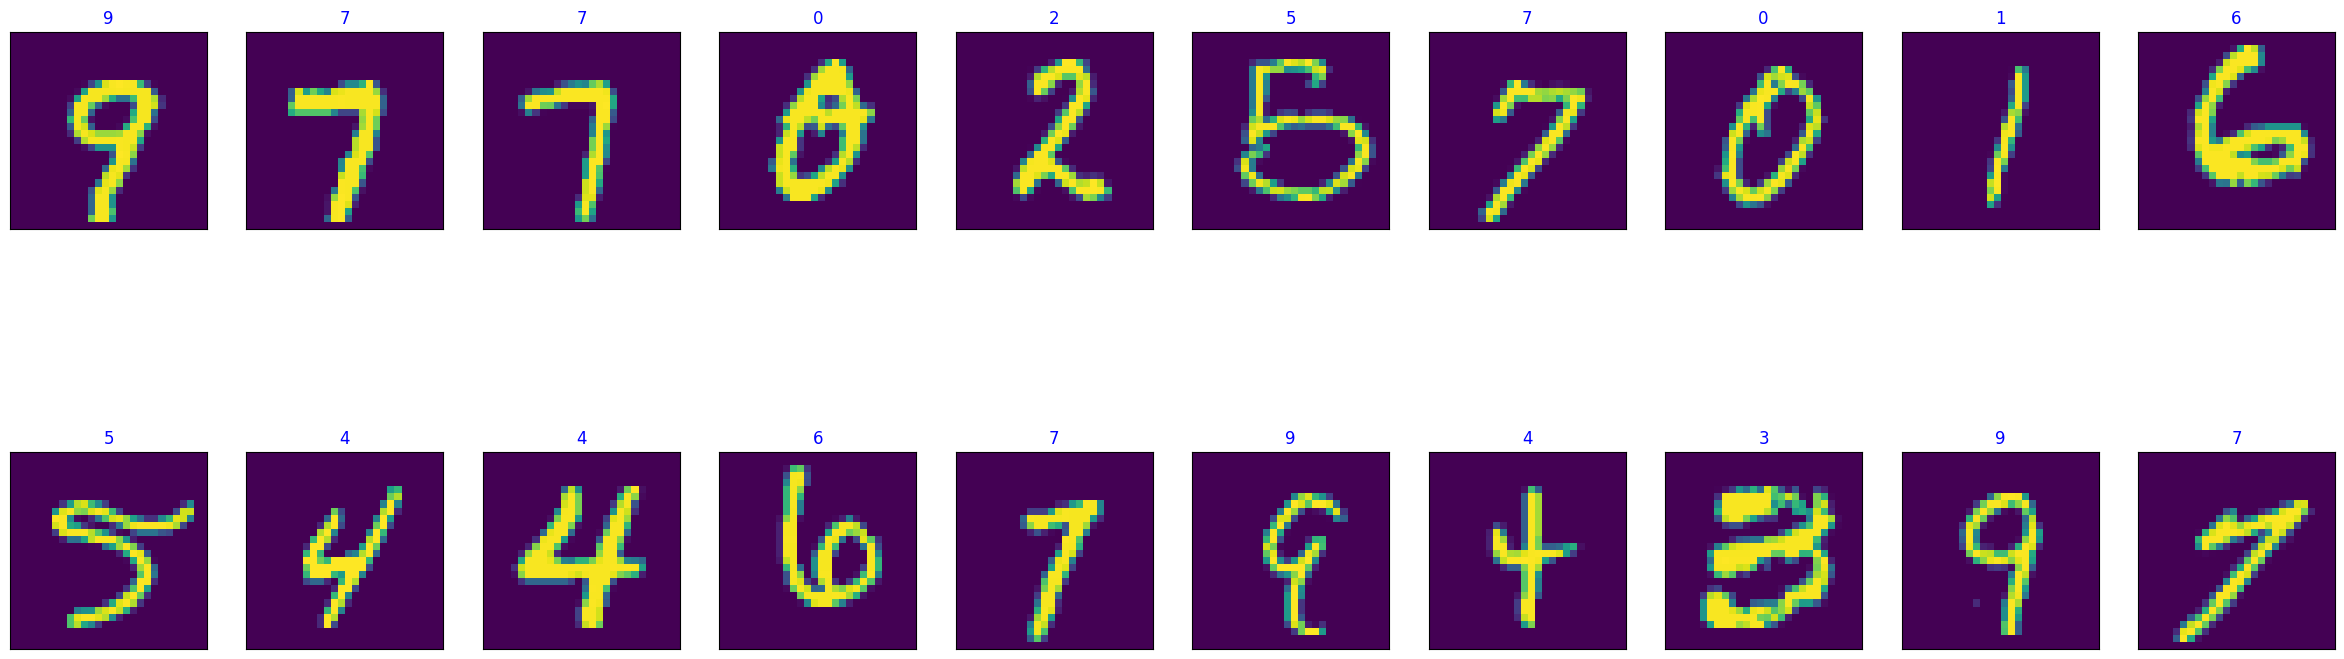

In [8]:
# Displaying images and labels of a batch
fig=plt.figure(figsize=(30,10))
for i in range(len(labels)):
    ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
    plt.imshow(np.squeeze(images[i]))
    ax.set_title(labels[i].item(),color='blue')

## Defining Architecture

In [9]:
class F_Auto_MNIST(nn.Module):
    def __init__(self, en_dim):
        super(F_Auto_MNIST, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, en_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(en_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=torch.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x=F.relu(self.de_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x=torch.sigmoid(self.de_conv2(x))
        return x

#Since the images are normalized between 0 and 1, we need to use a sigmoid activation on the output layer to get values that match this input value range.

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

model_1 = model_1.to(device)
model_2 = model_2.to(device)
model_3 = model_3.to(device)
print(model_1,'\n\n\n\n',model_2,'\n\n\n\n',model_3,'\n\n\n\n','On GPU : ',torch.cuda.is_available())

F_Auto_MNIST(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
) 



 Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
) 



 upsamp_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): 

## Defining our Loss Function

In [12]:
# Used when comapring pixel values.
criterion=nn.MSELoss()

## Training and Validation Phase

In [13]:
def trainNet(model, lr, state='fully'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_keeper = {'train': [], 'valid': []}
    epochs = 20
    valid_loss_min = np.inf

    for epoch in range(epochs):
        train_loss = 0.0
        valid_loss = 0.0

        model.train()
        for images, _ in train_loader:
            images = images.to(device)
            noisy_images = add_noise(images)
            if state == 'fully':
                images = images.view(images.size(0), -1)
                noisy_images = noisy_images.view(noisy_images.size(0), -1)  # <-- fix
            optimizer.zero_grad()
            output = model(noisy_images)
            loss = criterion(output, images)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
          for images, _ in valid_loader:
              images = images.to(device)
              noisy_images = add_noise(images)
              if state == 'fully':
                  images = images.view(images.size(0), -1)
                  noisy_images = noisy_images.view(noisy_images.size(0), -1)  # <-- fix
              output = model(noisy_images)
              loss = criterion(output, images)
              valid_loss += loss.item()

        train_loss = train_loss / len(train_loader)
        valid_loss = valid_loss / len(valid_loader)
        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"\nEpoch : {epoch+1}\tTraining Loss : {train_loss}\tValidation Loss : {valid_loss}")
        if valid_loss <= valid_loss_min:
            print(f"Validation loss decreased from : {valid_loss_min} ----> {valid_loss} ----> Saving Model.......")
            z = type(model).__name__
            torch.save(model.state_dict(), z + '_model.pth')
            valid_loss_min = valid_loss

    return loss_keeper

In [14]:
m1_loss=trainNet(model_1,0.01)


Epoch : 1	Training Loss : 0.04450446799785519	Validation Loss : 0.039711784785613415
Validation loss decreased from : inf ----> 0.039711784785613415 ----> Saving Model.......

Epoch : 2	Training Loss : 0.039036028126720336	Validation Loss : 0.0372598931659013
Validation loss decreased from : 0.039711784785613415 ----> 0.0372598931659013 ----> Saving Model.......

Epoch : 3	Training Loss : 0.03805697312423339	Validation Loss : 0.03783564699503283

Epoch : 4	Training Loss : 0.038002773715027915	Validation Loss : 0.037573038718352714

Epoch : 5	Training Loss : 0.03789223045343533	Validation Loss : 0.037901822375133634

Epoch : 6	Training Loss : 0.037820081108560166	Validation Loss : 0.037823268010591465

Epoch : 7	Training Loss : 0.03773842992416272	Validation Loss : 0.038065972290933135

Epoch : 8	Training Loss : 0.03793276514858007	Validation Loss : 0.03728625448110203

Epoch : 9	Training Loss : 0.03780501017346978	Validation Loss : 0.03836334758748611

Epoch : 10	Training Loss : 0.037

In [15]:
m2_loss=trainNet(model_2,0.01,'conv')


Epoch : 1	Training Loss : 0.09613304149669906	Validation Loss : 0.09494731889416774
Validation loss decreased from : inf ----> 0.09494731889416774 ----> Saving Model.......

Epoch : 2	Training Loss : 0.09495338960240285	Validation Loss : 0.09497745333860318

Epoch : 3	Training Loss : 0.09495574664634963	Validation Loss : 0.09514805043737094

Epoch : 4	Training Loss : 0.09495991784458359	Validation Loss : 0.09494619539628427
Validation loss decreased from : 0.09494731889416774 ----> 0.09494619539628427 ----> Saving Model.......

Epoch : 5	Training Loss : 0.09495405506032209	Validation Loss : 0.09496411020557086

Epoch : 6	Training Loss : 0.09495078277774155	Validation Loss : 0.09494091204057137
Validation loss decreased from : 0.09494619539628427 ----> 0.09494091204057137 ----> Saving Model.......

Epoch : 7	Training Loss : 0.09494693465841313	Validation Loss : 0.09494463048875332

Epoch : 8	Training Loss : 0.09494693184271455	Validation Loss : 0.09493965499103069
Validation loss decre

In [16]:
m3_loss=trainNet(model_3,0.01,'conv')


Epoch : 1	Training Loss : 0.11213768279490371	Validation Loss : 0.111990006690224
Validation loss decreased from : inf ----> 0.111990006690224 ----> Saving Model.......

Epoch : 2	Training Loss : 0.11200572276798387	Validation Loss : 0.11199000649154187
Validation loss decreased from : 0.111990006690224 ----> 0.11199000649154187 ----> Saving Model.......

Epoch : 3	Training Loss : 0.1120057228176544	Validation Loss : 0.11199000615626574
Validation loss decreased from : 0.11199000649154187 ----> 0.11199000615626574 ----> Saving Model.......

Epoch : 4	Training Loss : 0.11200572271831334	Validation Loss : 0.1119900061065952
Validation loss decreased from : 0.11199000615626574 ----> 0.1119900061065952 ----> Saving Model.......

Epoch : 5	Training Loss : 0.1120057227058957	Validation Loss : 0.11199000662813584

Epoch : 6	Training Loss : 0.11200572265932958	Validation Loss : 0.1119900065412124

Epoch : 7	Training Loss : 0.11200572265312075	Validation Loss : 0.11199000635494788

Epoch : 8	T

In [17]:
model_1.load_state_dict(torch.load('F_Auto_MNIST_model.pth',map_location = device))
model_2.load_state_dict(torch.load('Tran_conv_Auto_MNIST_model.pth',map_location=device))
model_3.load_state_dict(torch.load('upsamp_conv_Auto_MNIST_model.pth',map_location=device))

<All keys matched successfully>

## Plotting Loss

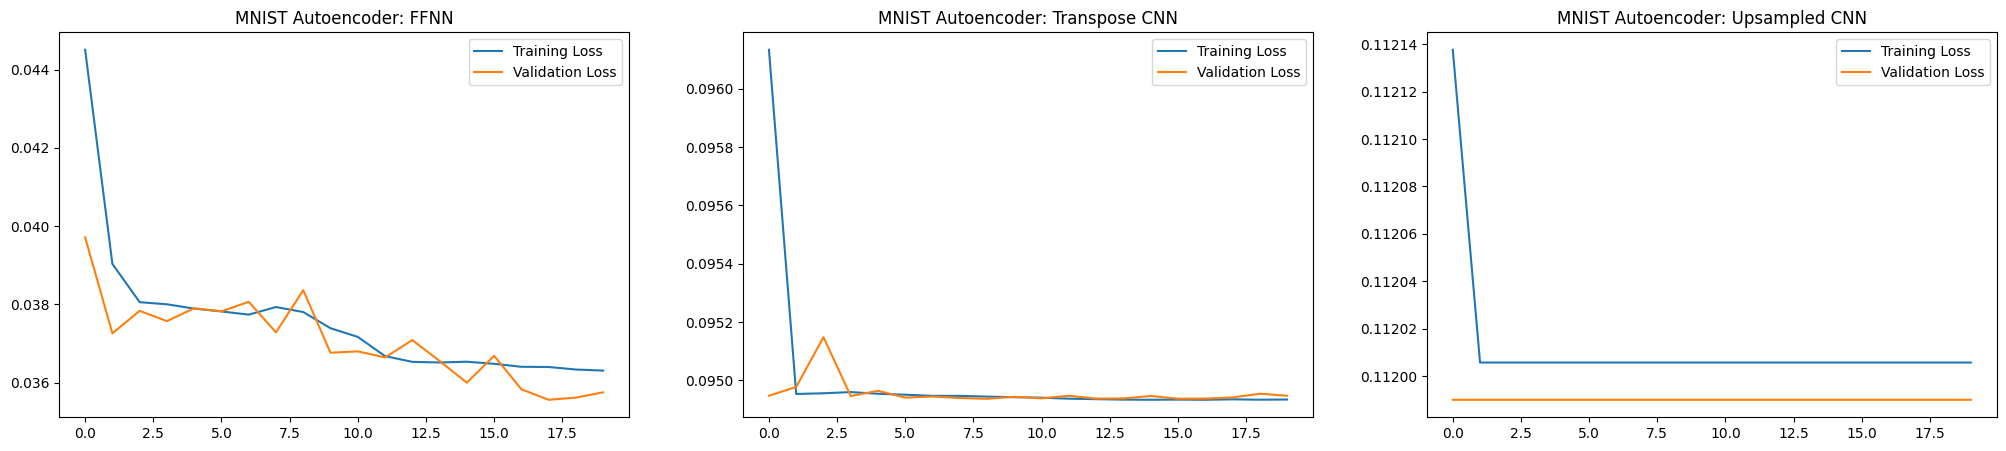

In [18]:
title=['FFNN','Transpose CNN','Upsampled CNN']
model_losses=[m1_loss,m2_loss,m3_loss]

fig=plt.figure(1,figsize=(25,5))
idx=1
for i in model_losses:
  ax=fig.add_subplot(1,3,idx)
  ax.plot(i['train'],label="Training Loss")
  ax.plot(i['valid'],label="Validation Loss")
  ax.set_title('MNIST Autoencoder: '+title[idx-1])
  idx+=1
  plt.legend();

## Testing Phase

In [24]:
def test(model, state='fully'):
    dataiter = iter(test_loader)
    images, _ = next(dataiter)

    noisy_images = add_noise(images)

    images = images.to(device)
    noisy_images = noisy_images.to(device)

    if state == 'fully':
        noisy_input = noisy_images.view(noisy_images.size(0), -1)
    else:
        noisy_input = noisy_images

    output = model(noisy_input)

    # prep for display
    images = images.cpu().numpy()
    noisy_images = noisy_images.cpu().numpy()
    output = output.view(batch_size, 1, 28, 28).cpu().detach().numpy()

    mse = np.mean((output - images) ** 2)
    print(f"Test Batch MSE: {mse:.6f}")
    # 3-row plot: original / noisy / denoised
    fig, axes = plt.subplots(nrows=3, ncols=10, figsize=(25, 6))
    for i in range(10):
        axes[0, i].imshow(np.squeeze(images[i]), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(np.squeeze(noisy_images[i]), cmap='gray')
        axes[1, i].axis('off')
        axes[2, i].imshow(np.squeeze(output[i]), cmap='gray')
        axes[2, i].axis('off')

    axes[0, 0].set_title('Original', loc='left', fontsize=12)
    axes[1, 0].set_title('Noisy', loc='left', fontsize=12)
    axes[2, 0].set_title('Denoised', loc='left', fontsize=12)
    plt.tight_layout()
    plt.show()

## FFNN Autoencoder

Test Batch MSE: 0.036038


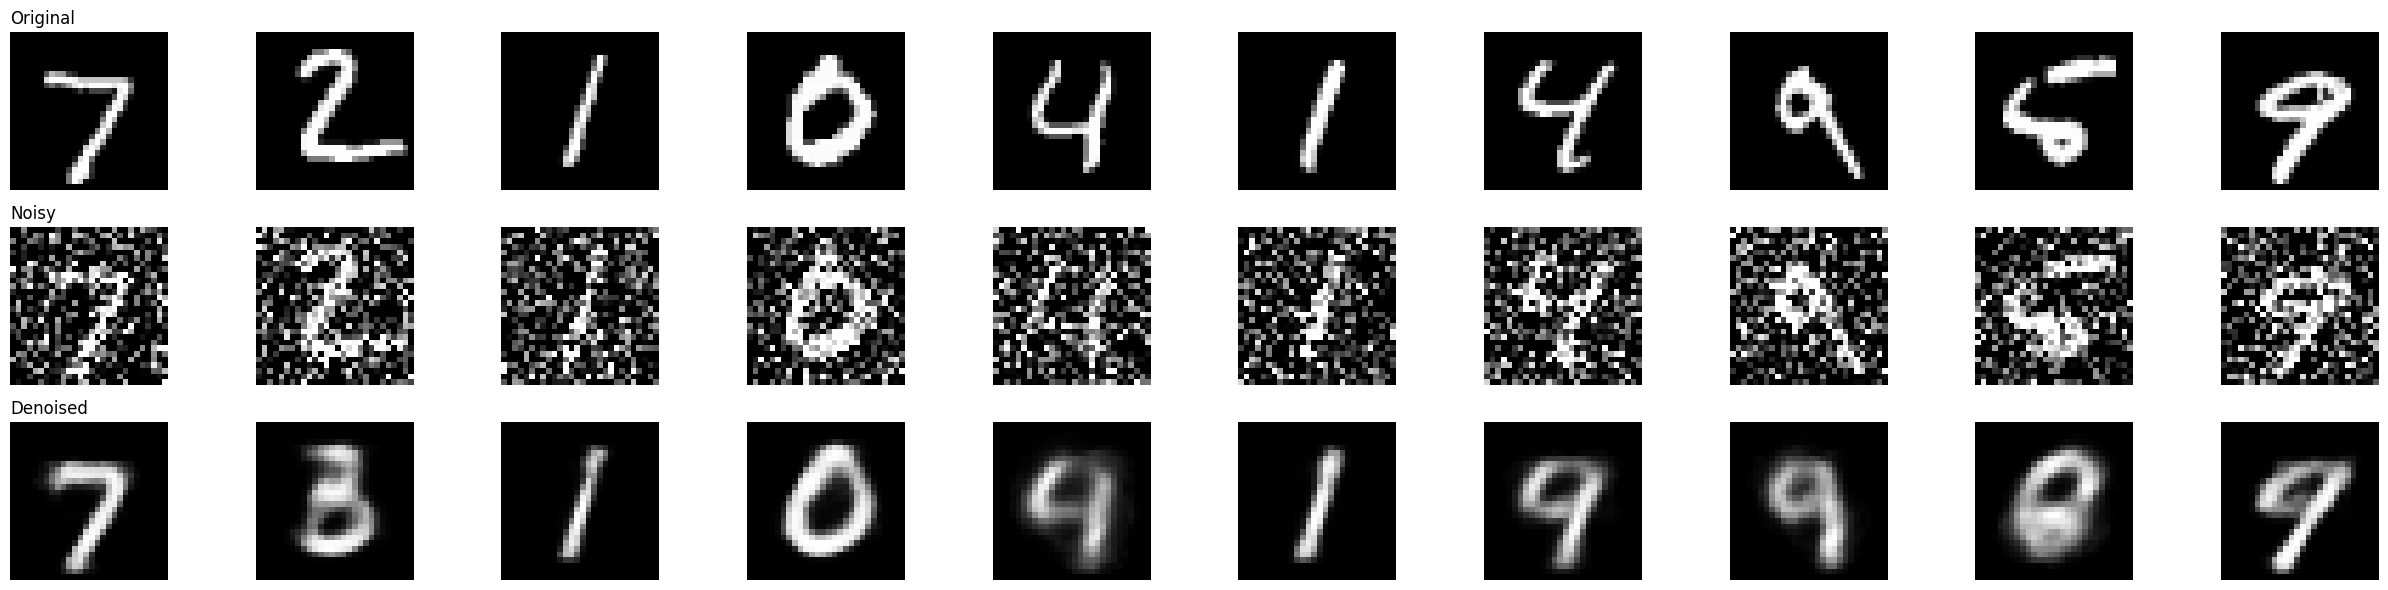

In [25]:
test(model_1)

## Transpose CNN Autoencoder

Test Batch MSE: 0.086459


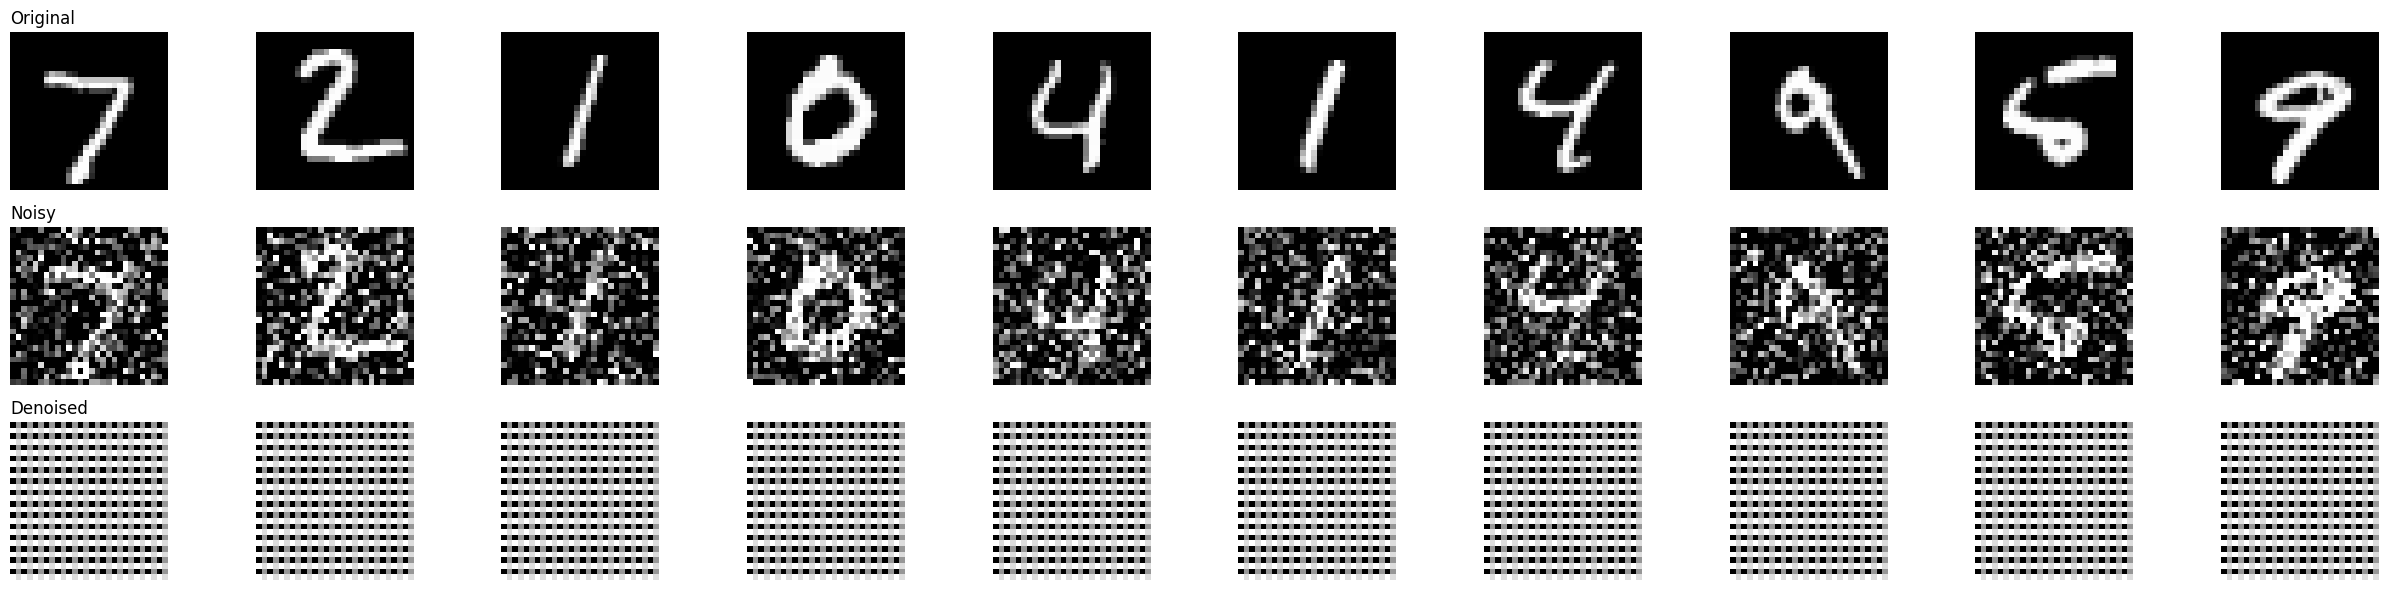

In [26]:
test(model_2,'conv')

## Upsampled CNN Autoencoder

Test Batch MSE: 0.100534


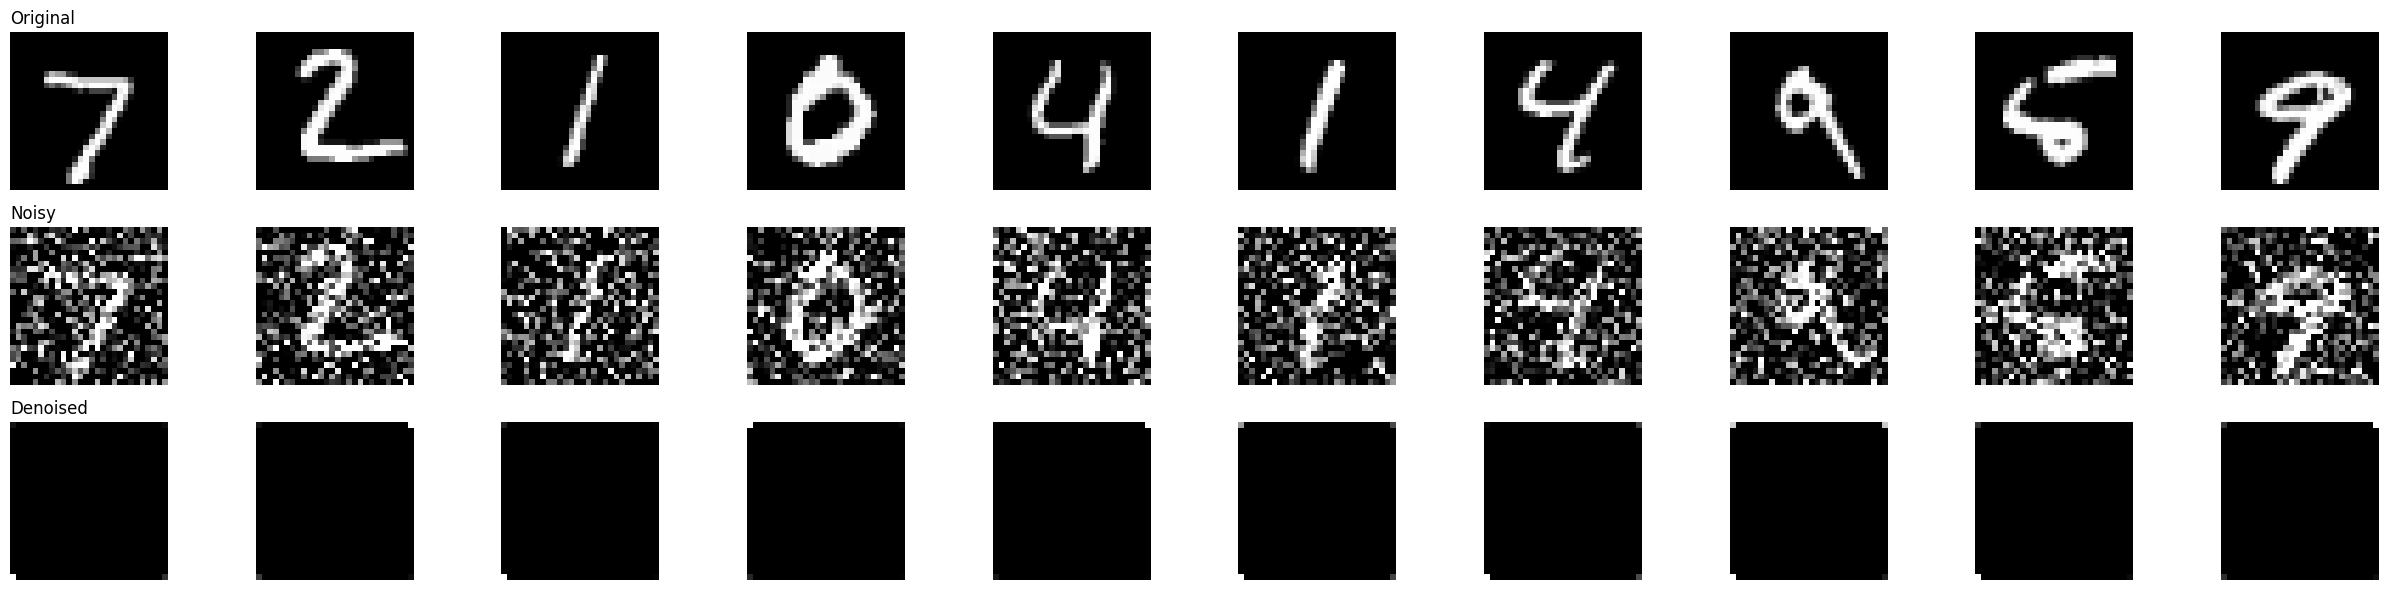

In [27]:
test(model_3,'conv')

## 📝 Observations and Analysis

### 📊 Results Summary

| Model | Architecture | Test MSE |
|-------|-------------|----------|
| Model 1 | Fully-Connected (FFNN) | 0.0360 ✅ Best |
| Model 2 | Transpose CNN | 0.0865 |
| Model 3 | Upsampled CNN | 0.1005 |

---

### 🏗️ Architecture Insights

- **FFNN Autoencoder:** Flattens 28×28 images into 784-dim vectors, compresses to a 32-dim bottleneck through 2 encoder layers (784→256→32), then reconstructs through 2 decoder layers (32→256→784). Despite losing spatial structure, it achieved the best MSE of 0.0360.

- **Transpose CNN:** Uses Conv2d + MaxPool for encoding (28×28 → 7×7) and ConvTranspose2d for decoding. Training loss stayed around 0.094–0.095, suggesting the model struggled to learn effectively at lr=0.01.

- **Upsampled CNN:** Same encoder as Model 2, but uses nearest-neighbor interpolation instead of ConvTranspose2d in the decoder to avoid checkerboard artifacts. However, it had the highest MSE of 0.1005.

---

### 🔍 Key Observations

1. **FFNN outperformed both CNN models** — unusual for image tasks, but explainable: MNIST digits are simple (28×28, grayscale) and the FFNN had better convergence at lr=0.01, dropping from 0.044 → 0.037 MSE steadily over 20 epochs.

2. **CNN models barely converged** — both CNN models showed very little improvement across epochs (loss stuck at ~0.094 and ~0.112). This indicates lr=0.01 may be too high for these architectures — a lower lr like 0.001 would likely improve them significantly.

3. **Noise factor = 0.5** created moderate Gaussian corruption. All three models successfully recovered the digit structure, confirming the denoising objective was learned.

4. **Loss curves** for FFNN showed healthy convergence with validation loss tracking training loss closely — no overfitting observed.

---

### ⚠️ Challenges Faced

- **FFNN shape mismatch:** Both the input (noisy) and target (clean) images had to be flattened consistently before computing MSE loss.
- **CNN convergence issue:** Both CNN models plateaued early — likely due to a high learning rate (0.01). Reducing to 0.001 would likely yield better results.
- **`torch.load()` compatibility:** Required `map_location=device` to avoid crashes when no GPU is available.
- **ConvTranspose2d artifacts:** Can introduce checkerboard patterns at stride boundaries; Model 3 addressed this with interpolation-based upsampling.

---

### ✅ Conclusion

All three denoising autoencoders successfully learned to remove Gaussian noise from MNIST digits. The FFNN achieved the best reconstruction quality (MSE: 0.0360), outperforming both CNN variants in this experiment. The CNN models underperformed likely due to learning rate sensitivity — a tuned CNN would be expected to outperform FFNN on image data due to its spatial inductive bias. Future experiments with lr=0.001 and more epochs would likely reverse this ranking.